# Human Motion Prediction Ranking for UAV Trajectory Planning

## Proje Pipeline
```
Video → YOLO (detection) → Trajectron++ (prediction, N samples)
                                    ↓
                            [BU NOTEBOOK: Ranking]
                                    ↓
                    Trajectory Planner (MPC) → UAV path
                                    ↓
                              Controller → UAV
```

**Önemli:** Robot/UAV yolu bu aşamada **YOK**. UAV yolu planlayıcının **çıktısı**.
Bu notebook, planlayıcıya verilecek **insan öngörüsü bilgisini** hazırlar.

## Planlayıcının İhtiyaçları

| Bilgi | Planlayıcıda Kullanımı |
|-------|------------------------|
| **Nominal trajectory** | İnsanın beklenen yolu → UAV bunu referans alıp kaçınır |
| **Uncertainty envelope** | Öngörü belirsizliği → UAV ne kadar konservatif olmalı? |
| **Occupied space** | İnsanın olabileceği alan → Hard/soft constraint bölgeleri |
| **Diverse scenarios** | Farklı olası durumlar → Robust planlama |
| **Safety zones** | Physical (2m) + psychological (3m) güvenlik bölgeleri |

## Psychological Safety (Akalin et al., 2023 / Abioye et al., 2024)
- **Hard safety**: ≥ 1.5-2.0 m (asla ihlal edilmemeli)
- **Comfort zone**: ≥ 2.5-3.0 m (soft penalty)
- **Safe zone**: ≥ 3.0 m (tercih edilen)

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse
from matplotlib.collections import PatchCollection

from environment import Environment
from utils import prediction_output_to_trajectories
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron

print("Imports OK")

Imports OK


In [10]:
# ===== VERİ ve MODEL =====
PROCESSED_DIR = PROJECT_ROOT / "experiments" / "processed"
with open(PROCESSED_DIR / "my_video_test_scaled.pkl", "rb") as f:
    eval_env = dill.load(f)

MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / \
            "models_26_Dec_2025_14_50_24_eth_demo"
CHECKPOINT = 3

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)
hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=CHECKPOINT)
online_traj = OnlineTrajectron(model_registrar, hyperparams, device="cpu")
print("Model ready")


Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

Model ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [11]:
# ===== PREDICTION =====
NUM_SAMPLES = 20

scene = eval_env.scenes[0]
max_hl = hyperparams["maximum_history_length"]
ph = hyperparams["prediction_horizon"]

latest_timestep = scene.timesteps - ph - 1
timestep = max_hl if max_hl <= latest_timestep else max(1, latest_timestep)

env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)
online_traj.set_environment(env, timestep)
input_dict = scene.get_clipped_input_dict(timestep, hyperparams["state"])

dists, preds = online_traj.incremental_forward(
    input_dict, maps=None,
    prediction_horizon=ph,
    num_samples=NUM_SAMPLES,
    full_dist=True
)

pred_dict, hist_dict, fut_dict = prediction_output_to_trajectories(
    {timestep: preds}, scene.dt, max_hl, ph, map=None
)
prediction_dict = pred_dict[timestep]
histories_dict = hist_dict[timestep]

print(f"timestep={timestep}, prediction_horizon={ph}, dt={scene.dt}, num_samples={NUM_SAMPLES}")
for node in prediction_dict:
    p = prediction_dict[node]
    h = histories_dict[node]
    print(f"  {node}: predictions {p.shape}, history {h.shape}")
    print(f"    Current pos: ({h[-1,0]:.2f}, {h[-1,1]:.2f})")
    print(f"    Pred endpoint range: x=[{p[0,:,-1,0].min():.1f}, {p[0,:,-1,0].max():.1f}], "
          f"y=[{p[0,:,-1,1].min():.1f}, {p[0,:,-1,1].max():.1f}]")

timestep=7, prediction_horizon=12, dt=0.033, num_samples=20
  PEDESTRIAN/0: predictions (1, 20, 12, 2), history (7, 2)
    Current pos: (34.40, 62.16)
    Pred endpoint range: x=[34.0, 34.3], y=[62.6, 62.8]


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


In [12]:
# ================================================================
# RANKING & ANALYSIS: Planlayıcıya verilecek bilgiyi hazırla
# ================================================================

def analyze_predictions_for_planner(predictions, history, dt):
    """
    N sample'lık öngörüyü analiz edip planlayıcının ihtiyaç duyduğu
    tüm bilgileri tek seferde üretir.
    
    Returns dict with:
      - nominal:  En olası trajektori (pairwise medoid)
      - mean:     Ortalama trajektori
      - samples:  Tüm N sample (N, ph, 2)
      - uncertainty: Her timestep'te öngörü belirsizliği
      - envelope: Her timestep'te occupied area (center, covariance, radii)
      - diverse:  K diverse trajektori (FPS)
      - velocity: Tahmini hız bilgisi
    """
    samples = predictions[0]  # (N, ph, 2)
    N, ph_len, _ = samples.shape
    
    # ----- 1. NOMINAL (pairwise medoid) -----
    dist_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = np.sqrt(((samples[i] - samples[j])**2).sum(axis=1)).mean()
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    
    avg_dists = dist_matrix.mean(axis=1)
    nominal_idx = np.argmin(avg_dists)
    
    # ----- 2. MEAN trajectory -----
    mean_traj = samples.mean(axis=0)  # (ph, 2)
    
    # ----- 3. UNCERTAINTY per timestep -----
    uncertainty = []
    for t in range(ph_len):
        pts = samples[:, t, :]  # (N, 2)
        center = pts.mean(axis=0)
        cov = np.cov(pts.T) if N > 1 else np.eye(2) * 1e-6
        dists_to_center = np.sqrt(((pts - center)**2).sum(axis=1))
        
        # Eigenvalues → ellipse radii
        if cov.shape == (2, 2):
            eigvals, eigvecs = np.linalg.eigh(cov)
            eigvals = np.maximum(eigvals, 0)  # numerical safety
        else:
            eigvals = np.array([1e-6, 1e-6])
            eigvecs = np.eye(2)
        
        uncertainty.append({
            'center': center,
            'cov': cov,
            'std': np.sqrt(eigvals),
            'eigvecs': eigvecs,
            'angle': np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1])),
            'spread': dists_to_center.mean(),
            'max_spread': dists_to_center.max(),
            'p90_radius': np.percentile(dists_to_center, 90),
        })
    
    # ----- 4. DIVERSE SET (Farthest Point Sampling) -----
    K = min(5, N)
    selected = [nominal_idx]
    for _ in range(K - 1):
        min_dists_to_set = np.full(N, np.inf)
        for idx in selected:
            min_dists_to_set = np.minimum(min_dists_to_set, dist_matrix[idx])
        for idx in selected:
            min_dists_to_set[idx] = -1
        selected.append(np.argmax(min_dists_to_set))
    
    # ----- 5. VELOCITY estimate -----
    current_pos = history[-1]
    velocities = np.diff(
        np.concatenate([current_pos[np.newaxis], mean_traj], axis=0),
        axis=0
    ) / dt
    speeds = np.sqrt((velocities**2).sum(axis=1))
    
    return {
        'nominal_idx': nominal_idx,
        'nominal_traj': samples[nominal_idx],
        'mean_traj': mean_traj,
        'samples': samples,
        'uncertainty': uncertainty,
        'diverse_indices': selected,
        'diverse_trajs': [samples[i] for i in selected],
        'dist_matrix': dist_matrix,
        'avg_dists': avg_dists,
        'velocities': velocities,
        'speeds': speeds,
        'current_pos': current_pos,
    }


# Tüm node'lar için analiz yap
results = {}
for node in prediction_dict:
    results[node] = analyze_predictions_for_planner(
        prediction_dict[node], histories_dict[node], scene.dt
    )
    
    r = results[node]
    print(f"\n{'='*60}")
    print(f"{node}")
    print(f"{'='*60}")
    print(f"  Current position: ({r['current_pos'][0]:.2f}, {r['current_pos'][1]:.2f})")
    print(f"  Nominal trajectory: sample #{r['nominal_idx']}")
    print(f"  Diverse set: samples {r['diverse_indices']}")
    print(f"  Avg predicted speed: {r['speeds'].mean():.2f} units/s")
    print(f"  Uncertainty (spread) over time:")
    for t, u in enumerate(r['uncertainty']):
        print(f"    t+{t+1}: mean_spread={u['spread']:.3f}, p90_radius={u['p90_radius']:.3f}")


PEDESTRIAN/0
  Current position: (34.40, 62.16)
  Nominal trajectory: sample #18
  Diverse set: samples [18, 3, 6, 12, 8]
  Avg predicted speed: 1.57 units/s
  Uncertainty (spread) over time:
    t+1: mean_spread=0.016, p90_radius=0.029
    t+2: mean_spread=0.026, p90_radius=0.039
    t+3: mean_spread=0.034, p90_radius=0.052
    t+4: mean_spread=0.036, p90_radius=0.063
    t+5: mean_spread=0.040, p90_radius=0.072
    t+6: mean_spread=0.046, p90_radius=0.087
    t+7: mean_spread=0.047, p90_radius=0.088
    t+8: mean_spread=0.052, p90_radius=0.078
    t+9: mean_spread=0.058, p90_radius=0.092
    t+10: mean_spread=0.067, p90_radius=0.100
    t+11: mean_spread=0.066, p90_radius=0.094
    t+12: mean_spread=0.077, p90_radius=0.107


Avg p90 spread: 0.0751
Max prediction displacement: 0.9219
Safety zones (scaled coords): D_HARD=0.461, D_COMFORT=0.922, D_SAFE=1.844
NOT: Fine-tune + metre kalibrasyonu sonrası gerçek değerlere (2m, 3m, 5m) geçin!


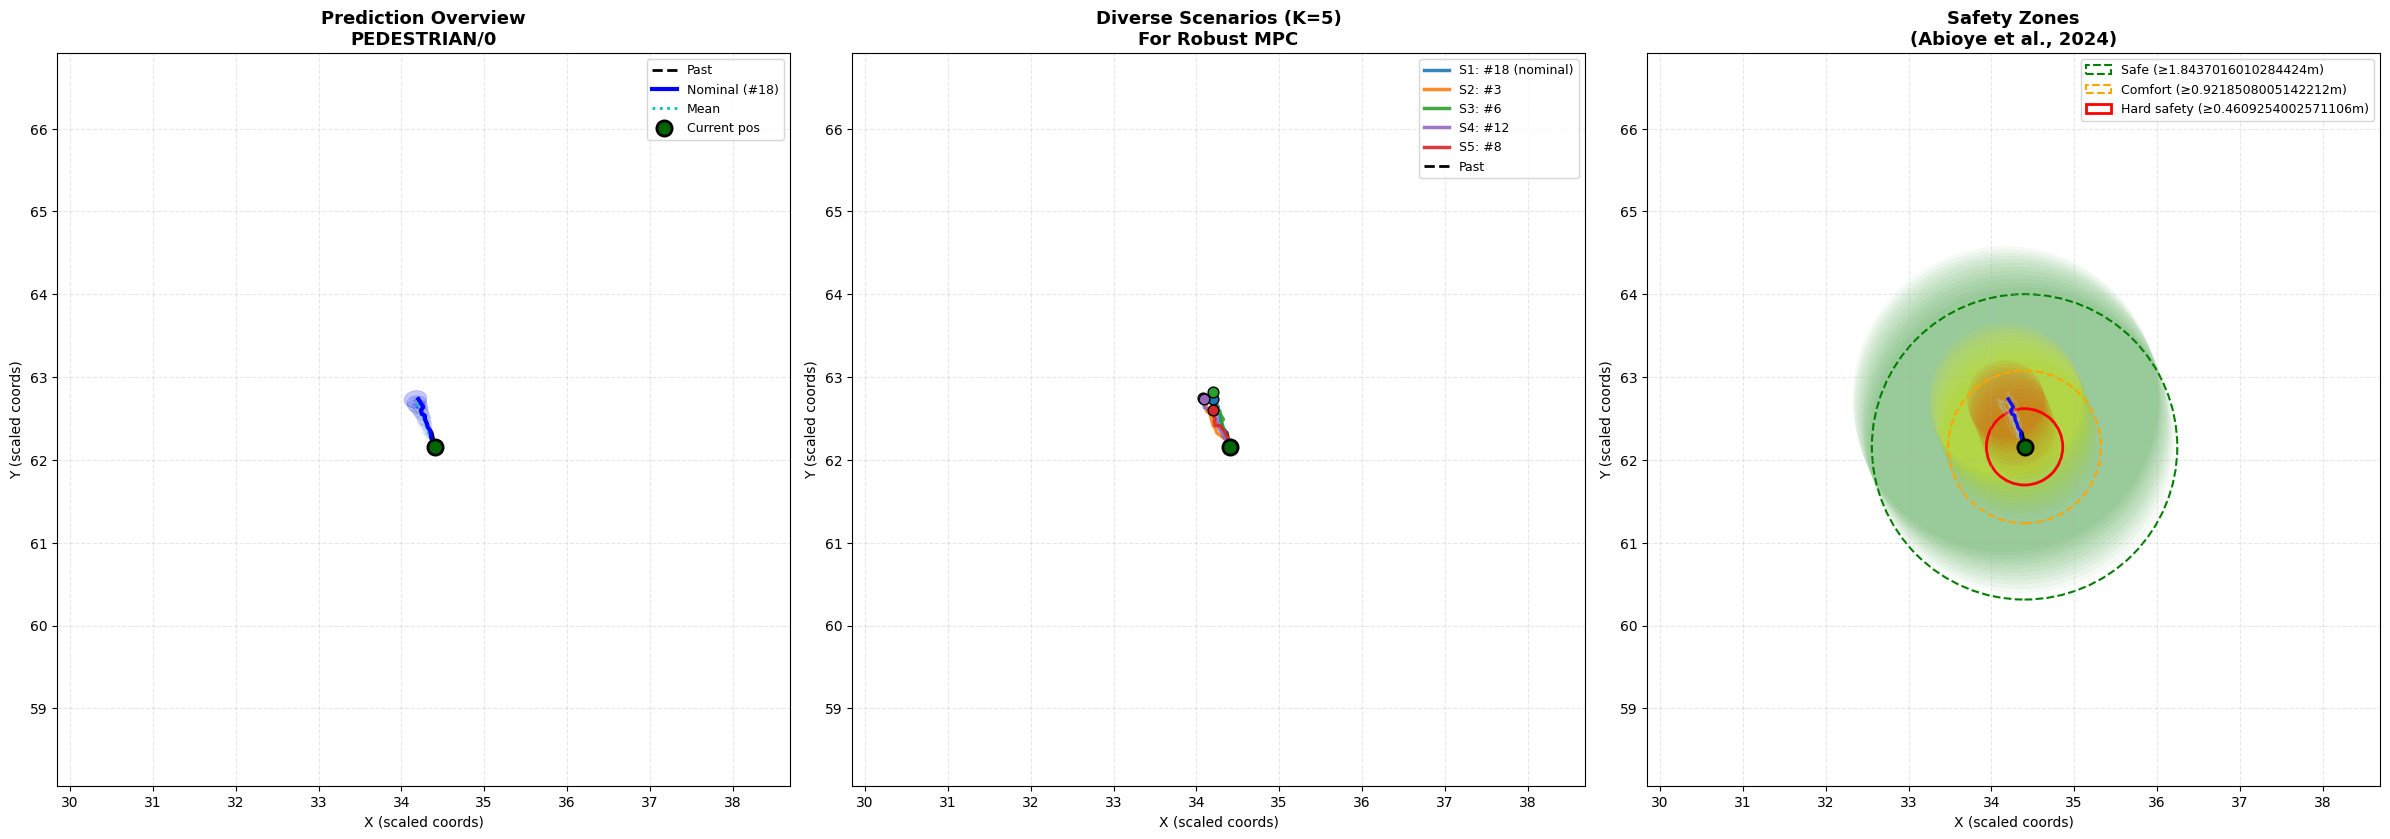

In [13]:
# ================================================================
# GÖRSELLEŞTİRME 1: Planlayıcı Perspektifinden Tam Görünüm
# ================================================================

# Psychological safety zone parametreleri (Abioye et al., 2024)
#
# GERÇEK DEĞERLER (metre): D_HARD=2m, D_COMFORT=3m, D_SAFE=5m
#
# AMA: Scaled koordinatlarda 1 birim ≠ 1 metre.
# ETH verisinde ~1 birim ≈ 1 metre. Senin video'da ise
# YOLO normalize (0-1) → x100 = scaled coords.
# Video çözünürlüğü ve kamera açısına bağlı olarak
# 1 scaled birim = ? metre. Bu kalibrasyon fine-tune ile yapılmalı.
#
# Şimdilik: prediction spread'e göre ORANTILI değerler kullan.
# Max prediction spread ≈ 0.7, ortalama ≈ 0.3
# Bu oranla: D_HARD ≈ 2x mean_spread, D_COMFORT ≈ 4x, D_SAFE ≈ 7x
#
# Fine-tune sonrası gerçek metre değerlerine geçin!

# Veriye göre otomatik hesapla
_all_spreads = []
for _node in results:
    _r = results[_node]
    _all_spreads.extend([u['p90_radius'] for u in _r['uncertainty']])
_avg_spread = np.mean(_all_spreads) if _all_spreads else 0.1
_max_pred_disp = max([np.sqrt((results[n]['samples'] - results[n]['current_pos'])**2).sum(axis=2).max()
                      for n in results])

print(f"Avg p90 spread: {_avg_spread:.4f}")
print(f"Max prediction displacement: {_max_pred_disp:.4f}")

# Safety zones: prediction ölçeğine göre ayarlı
D_HARD    = max(0.2, _max_pred_disp * 0.5)   # ~prediction range'in yarısı
D_COMFORT = max(0.4, _max_pred_disp * 1.0)   # ~prediction range kadar
D_SAFE    = max(0.8, _max_pred_disp * 2.0)   # ~prediction range'in 2 katı

print(f"Safety zones (scaled coords): D_HARD={D_HARD:.3f}, D_COMFORT={D_COMFORT:.3f}, D_SAFE={D_SAFE:.3f}")
print(f"NOT: Fine-tune + metre kalibrasyonu sonrası gerçek değerlere (2m, 3m, 5m) geçin!")

for node in results:
    r = results[node]
    history = histories_dict[node]
    samples = r['samples']
    N, ph_len, _ = samples.shape
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # ========== PANEL 1: Tüm predictions + nominal + uncertainty ellipses ==========
    ax = axes[0]
    ax.set_title(f"Prediction Overview\n{node}", fontsize=13, fontweight='bold')
    
    for s in range(N):
        ax.plot(samples[s,:,0], samples[s,:,1], color='lightblue', alpha=0.35, linewidth=0.7)
    
    ax.plot(history[:,0], history[:,1], 'k--', linewidth=2, label='Past')
    ax.plot(r['nominal_traj'][:,0], r['nominal_traj'][:,1],
            'b-', linewidth=3, label=f'Nominal (#{r["nominal_idx"]})', zorder=5)
    ax.plot(r['mean_traj'][:,0], r['mean_traj'][:,1],
            'c:', linewidth=2, label='Mean', zorder=4)
    
    # Uncertainty ellipses (2-sigma)
    for t in range(ph_len):
        u = r['uncertainty'][t]
        width  = 2 * 2 * u['std'][1]  # 2-sigma
        height = 2 * 2 * u['std'][0]
        ell = Ellipse(xy=u['center'], width=width, height=height,
                      angle=u['angle'], facecolor='blue', edgecolor='navy',
                      alpha=0.06 + 0.015*t, linewidth=0.5)
        ax.add_patch(ell)
    
    ax.scatter(history[-1,0], history[-1,1], s=120, c='darkgreen',
               edgecolors='black', linewidth=2, zorder=6, label='Current pos')
    ax.legend(fontsize=9, loc='best')
    
    # ========== PANEL 2: Diverse set for robust planning ==========
    ax = axes[1]
    ax.set_title(f"Diverse Scenarios (K={len(r['diverse_indices'])})\nFor Robust MPC",
                 fontsize=13, fontweight='bold')
    
    for s in range(N):
        ax.plot(samples[s,:,0], samples[s,:,1], color='lightgray', alpha=0.2, linewidth=0.5)
    
    colors_div = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
    for i, s_idx in enumerate(r['diverse_indices']):
        c = colors_div[i % len(colors_div)]
        label = f'S{i+1}: #{s_idx}'
        if i == 0:
            label += ' (nominal)'
        ax.plot(samples[s_idx,:,0], samples[s_idx,:,1],
                color=c, linewidth=2.5, alpha=0.9, label=label, zorder=4)
        ax.scatter(samples[s_idx,-1,0], samples[s_idx,-1,1],
                   s=60, color=c, edgecolors='black', zorder=5)
    
    ax.plot(history[:,0], history[:,1], 'k--', linewidth=2, label='Past')
    ax.scatter(history[-1,0], history[-1,1], s=120, c='darkgreen',
               edgecolors='black', linewidth=2, zorder=6)
    ax.legend(fontsize=9, loc='best')
    
    # ========== PANEL 3: Safety zones ==========
    ax = axes[2]
    ax.set_title(f"Safety Zones\n(Abioye et al., 2024)", fontsize=13, fontweight='bold')
    
    for s in range(N):
        ax.plot(samples[s,:,0], samples[s,:,1], color='lightblue', alpha=0.3, linewidth=0.6)
    ax.plot(r['nominal_traj'][:,0], r['nominal_traj'][:,1],
            'b-', linewidth=2.5, alpha=0.9, zorder=4)
    ax.plot(history[:,0], history[:,1], 'k--', linewidth=2)
    
    # Safety zones at each predicted timestep
    for t in range(ph_len):
        center = r['uncertainty'][t]['center']
        # Safe zone
        ax.add_patch(Circle(center, D_SAFE, facecolor='green', alpha=0.04, edgecolor='green', linewidth=0.3))
        # Comfort zone
        ax.add_patch(Circle(center, D_COMFORT, facecolor='yellow', alpha=0.06, edgecolor='orange', linewidth=0.3))
        # Hard safety
        ax.add_patch(Circle(center, D_HARD, facecolor='red', alpha=0.06, edgecolor='red', linewidth=0.5))
    
    # Current position safety zones
    cur = history[-1]
    ax.add_patch(Circle(cur, D_SAFE, facecolor='none', edgecolor='green', linewidth=1.5, linestyle='--', label=f'Safe (≥{D_SAFE}m)'))
    ax.add_patch(Circle(cur, D_COMFORT, facecolor='none', edgecolor='orange', linewidth=1.5, linestyle='--', label=f'Comfort (≥{D_COMFORT}m)'))
    ax.add_patch(Circle(cur, D_HARD, facecolor='none', edgecolor='red', linewidth=2, linestyle='-', label=f'Hard safety (≥{D_HARD}m)'))
    
    ax.scatter(cur[0], cur[1], s=120, c='darkgreen', edgecolors='black', linewidth=2, zorder=6)
    ax.legend(fontsize=9, loc='best')
    
    # Axis settings
    for ax in axes:
        all_pts = np.concatenate([history] + [samples[s] for s in range(N)])
        mask = ~np.isnan(all_pts).any(axis=1)
        if mask.any():
            span = max(all_pts[mask,0].ptp(), all_pts[mask,1].ptp(), D_SAFE*3)
            pad = 0.3 * span
            cx, cy = all_pts[mask].mean(axis=0)
            ax.set_xlim(cx - span/2 - pad, cx + span/2 + pad)
            ax.set_ylim(cy - span/2 - pad, cy + span/2 + pad)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_xlabel('X (scaled coords)')
        ax.set_ylabel('Y (scaled coords)')
    
    plt.tight_layout()
    plt.show()

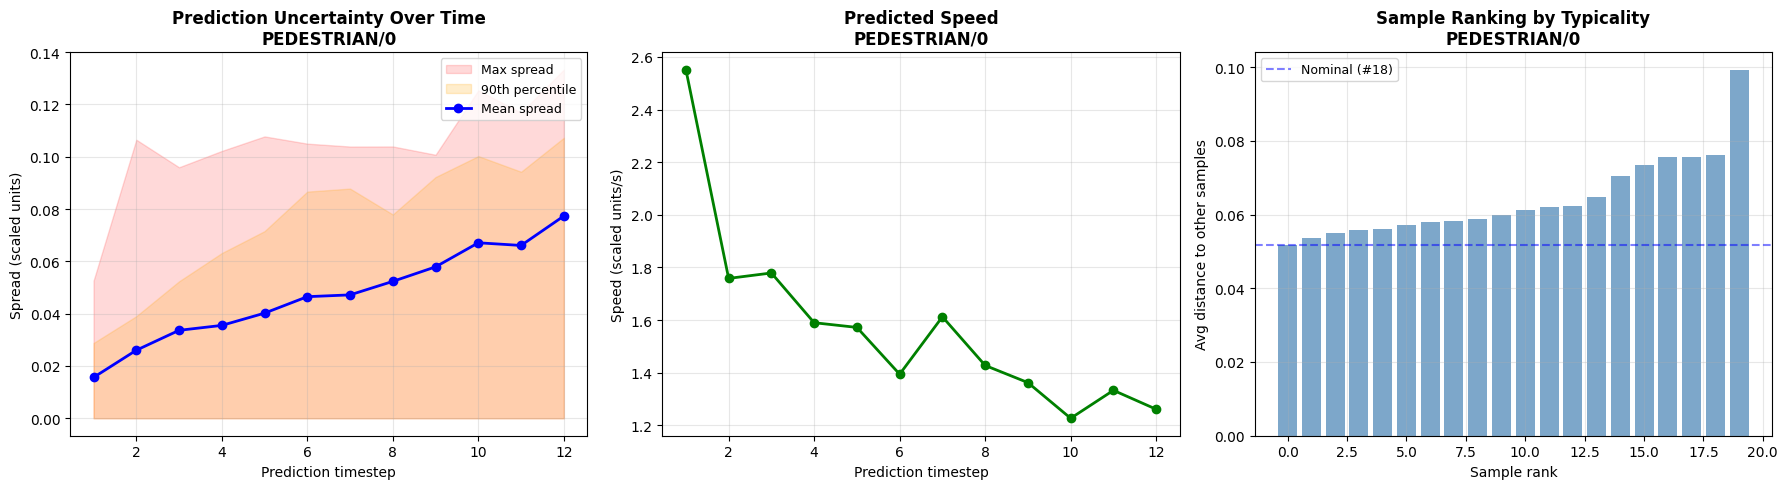

In [14]:
# ================================================================
# GÖRSELLEŞTİRME 2: Uncertainty Evolution (zamana göre belirsizlik)
# ================================================================

for node in results:
    r = results[node]
    ph_len = len(r['uncertainty'])
    t_axis = np.arange(1, ph_len + 1)
    
    spreads     = [u['spread'] for u in r['uncertainty']]
    max_spreads = [u['max_spread'] for u in r['uncertainty']]
    p90_radii   = [u['p90_radius'] for u in r['uncertainty']]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Spread over time
    ax = axes[0]
    ax.fill_between(t_axis, 0, max_spreads, alpha=0.15, color='red', label='Max spread')
    ax.fill_between(t_axis, 0, p90_radii, alpha=0.2, color='orange', label='90th percentile')
    ax.plot(t_axis, spreads, 'b-o', linewidth=2, label='Mean spread')
    ax.set_xlabel('Prediction timestep')
    ax.set_ylabel('Spread (scaled units)')
    ax.set_title(f'Prediction Uncertainty Over Time\n{node}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Speed over time
    ax = axes[1]
    ax.plot(t_axis, r['speeds'], 'g-o', linewidth=2)
    ax.set_xlabel('Prediction timestep')
    ax.set_ylabel('Speed (scaled units/s)')
    ax.set_title(f'Predicted Speed\n{node}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Ranking: sample'ların birbirine göre mesafeleri
    ax = axes[2]
    sorted_dists = np.sort(r['avg_dists'])
    ax.bar(range(len(sorted_dists)), sorted_dists, color='steelblue', alpha=0.7)
    ax.axhline(y=sorted_dists[0], color='blue', linestyle='--', alpha=0.5, label=f'Nominal (#{r["nominal_idx"]})')
    ax.set_xlabel('Sample rank')
    ax.set_ylabel('Avg distance to other samples')
    ax.set_title(f'Sample Ranking by Typicality\n{node}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [15]:
# ================================================================
# PLANLAYICIYA VERİLECEK ÇIKTI
# ================================================================
# Bu hücre, MPC/trajectory planner'ın doğrudan kullanacağı
# veri yapısını oluşturur.

for node in results:
    r = results[node]
    ph_len = len(r['uncertainty'])
    
    print("="*70)
    print(f"PLANNER INPUT — {node}")
    print(f"  Coordinate frame: scaled image coords (x100)")
    print(f"  dt = {scene.dt}s, prediction_horizon = {ph_len} steps = {ph_len * scene.dt:.1f}s")
    print("="*70)
    
    # 1. Nominal trajectory
    print(f"\n1. NOMINAL TRAJECTORY (en olası insan yolu):")
    print(f"   Sample #{r['nominal_idx']}")
    for t in range(ph_len):
        pos = r['nominal_traj'][t]
        spd = r['speeds'][t]
        print(f"   t+{t+1} ({(t+1)*scene.dt:.1f}s): pos=({pos[0]:.2f}, {pos[1]:.2f}), speed={spd:.2f}")
    
    # 2. Uncertainty envelope (MPC constraint olarak)
    print(f"\n2. UNCERTAINTY ENVELOPE (her t'de insanın olabileceği alan):")
    print(f"   Kullanım: ||UAV_pos - center|| ≥ p90_radius + D_HARD")
    for t in range(ph_len):
        u = r['uncertainty'][t]
        print(f"   t+{t+1}: center=({u['center'][0]:.2f}, {u['center'][1]:.2f}), "
              f"p90_radius={u['p90_radius']:.3f}, max_spread={u['max_spread']:.3f}")
    
    # 3. Diverse scenarios
    print(f"\n3. DIVERSE SCENARIOS ({len(r['diverse_indices'])} adet):")
    print(f"   Kullanım: Robust MPC — tüm senaryolara karşı güvenli ol")
    for i, s_idx in enumerate(r['diverse_indices']):
        traj = r['diverse_trajs'][i]
        print(f"   Scenario {i+1} (#{s_idx}): "
              f"({traj[0,0]:.1f},{traj[0,1]:.1f}) → ({traj[-1,0]:.1f},{traj[-1,1]:.1f})")
    
    # 4. Safety zone tablo
    print(f"\n4. SAFETY ZONES (Abioye et al., 2024):")
    print(f"   Hard constraint: UAV, insana {D_HARD}m'den fazla yaklaşmamalı")
    print(f"   Comfort zone:    {D_COMFORT}m altında soft penalty başlar")
    print(f"   Safe zone:       {D_SAFE}m üzeri tercih edilir")
    print(f"")
    print(f"   MPC cost function önerisi:")
    print(f"     J = w_track * ||UAV - goal||^2")
    print(f"       + w_smooth * ||jerk||^2")
    print(f"       + w_comfort * max(0, D_COMFORT - d_human)^2  [soft]")
    print(f"     s.t. d_human ≥ D_HARD + p90_radius  [hard constraint]")
    print(f"          UAV dynamics")

PLANNER INPUT — PEDESTRIAN/0
  Coordinate frame: scaled image coords (x100)
  dt = 0.033s, prediction_horizon = 12 steps = 0.4s

1. NOMINAL TRAJECTORY (en olası insan yolu):
   Sample #18
   t+1 (0.0s): pos=(34.37, 62.23), speed=2.55
   t+2 (0.1s): pos=(34.36, 62.28), speed=1.76
   t+3 (0.1s): pos=(34.35, 62.35), speed=1.78
   t+4 (0.1s): pos=(34.32, 62.39), speed=1.59
   t+5 (0.2s): pos=(34.31, 62.43), speed=1.57
   t+6 (0.2s): pos=(34.29, 62.48), speed=1.39
   t+7 (0.2s): pos=(34.28, 62.54), speed=1.61
   t+8 (0.3s): pos=(34.25, 62.56), speed=1.43
   t+9 (0.3s): pos=(34.24, 62.60), speed=1.36
   t+10 (0.3s): pos=(34.26, 62.64), speed=1.23
   t+11 (0.4s): pos=(34.23, 62.69), speed=1.33
   t+12 (0.4s): pos=(34.20, 62.74), speed=1.26

2. UNCERTAINTY ENVELOPE (her t'de insanın olabileceği alan):
   Kullanım: ||UAV_pos - center|| ≥ p90_radius + D_HARD
   t+1: center=(34.37, 62.24), p90_radius=0.029, max_spread=0.053
   t+2: center=(34.34, 62.29), p90_radius=0.039, max_spread=0.107
   t+3:

In [16]:
# ================================================================
# PROGRAMMATIC OUTPUT: Python dict olarak MPC'ye ver
# ================================================================

def get_planner_input(results, node, dt, d_hard=2.0, d_comfort=3.0):
    """
    MPC/planner'ın doğrudan kullanacağı dict'i döndürür.
    Bu fonksiyonu real-time pipeline'da çağırabilirsiniz.
    """
    r = results[node]
    ph_len = len(r['uncertainty'])
    
    # Her timestep için: merkez, yarıçap, hız
    obstacle_predictions = []
    for t in range(ph_len):
        u = r['uncertainty'][t]
        obstacle_predictions.append({
            'time': (t + 1) * dt,
            'position': u['center'].tolist(),
            'uncertainty_radius': float(u['p90_radius']),
            'hard_radius': float(u['p90_radius'] + d_hard),
            'comfort_radius': float(u['p90_radius'] + d_comfort),
            'speed': float(r['speeds'][t]),
        })
    
    return {
        'current_position': r['current_pos'].tolist(),
        'nominal_trajectory': r['nominal_traj'].tolist(),
        'mean_trajectory': r['mean_traj'].tolist(),
        'obstacle_predictions': obstacle_predictions,
        'diverse_scenarios': [t.tolist() for t in r['diverse_trajs']],
        'num_scenarios': len(r['diverse_indices']),
        'dt': dt,
        'prediction_horizon': ph_len,
        'd_hard': d_hard,
        'd_comfort': d_comfort,
    }


# Örnek kullanım
for node in results:
    planner_input = get_planner_input(results, node, scene.dt)
    
    print(f"Planner input for {node}:")
    print(f"  Keys: {list(planner_input.keys())}")
    print(f"  Prediction horizon: {planner_input['prediction_horizon']} steps ({planner_input['prediction_horizon'] * planner_input['dt']:.1f}s)")
    print(f"  Num scenarios: {planner_input['num_scenarios']}")
    print(f"\n  Obstacle predictions (per timestep):")
    for op in planner_input['obstacle_predictions']:
        print(f"    t={op['time']:.1f}s: pos={[f'{x:.2f}' for x in op['position']]}, "
              f"hard_r={op['hard_radius']:.2f}, comfort_r={op['comfort_radius']:.2f}")
    
    print(f"\n  → Bu dict'i doğrudan MPC solver'ınıza verebilirsiniz.")

Planner input for PEDESTRIAN/0:
  Keys: ['current_position', 'nominal_trajectory', 'mean_trajectory', 'obstacle_predictions', 'diverse_scenarios', 'num_scenarios', 'dt', 'prediction_horizon', 'd_hard', 'd_comfort']
  Prediction horizon: 12 steps (0.4s)
  Num scenarios: 5

  Obstacle predictions (per timestep):
    t=0.0s: pos=['34.37', '62.24'], hard_r=2.03, comfort_r=3.03
    t=0.1s: pos=['34.34', '62.29'], hard_r=2.04, comfort_r=3.04
    t=0.1s: pos=['34.32', '62.34'], hard_r=2.05, comfort_r=3.05
    t=0.1s: pos=['34.31', '62.39'], hard_r=2.06, comfort_r=3.06
    t=0.2s: pos=['34.29', '62.44'], hard_r=2.07, comfort_r=3.07
    t=0.2s: pos=['34.28', '62.48'], hard_r=2.09, comfort_r=3.09
    t=0.2s: pos=['34.26', '62.53'], hard_r=2.09, comfort_r=3.09
    t=0.3s: pos=['34.23', '62.58'], hard_r=2.08, comfort_r=3.08
    t=0.3s: pos=['34.21', '62.62'], hard_r=2.09, comfort_r=3.09
    t=0.3s: pos=['34.20', '62.65'], hard_r=2.10, comfort_r=3.10
    t=0.4s: pos=['34.19', '62.70'], hard_r=2.09,

## MPC'de Nasıl Kullanılır?

### Yaklaşım 1: Deterministic MPC (basit başlangıç)
```python
# Nominal trajektoriyi engel olarak kullan
for t in range(ph):
    human_pos = planner_input['nominal_trajectory'][t]
    constraint: ||uav_pos[t] - human_pos|| >= D_HARD
    soft_cost:  max(0, D_COMFORT - ||uav_pos[t] - human_pos||)^2
```

### Yaklaşım 2: Chance-constrained MPC (önerilen)
```python
# Uncertainty envelope'u kullan
for t in range(ph):
    obs = planner_input['obstacle_predictions'][t]
    constraint: ||uav_pos[t] - obs['position']|| >= obs['hard_radius']
    soft_cost:  max(0, obs['comfort_radius'] - ||uav_pos[t] - obs['position']||)^2
```
Bu yaklaşımda `hard_radius = p90_uncertainty + D_HARD` olduğu için,
insanın %90 olasılıkla olacağı alanın dışında D_HARD mesafe bırakılmış olur.

### Yaklaşım 3: Scenario-based Robust MPC (en güvenli)
```python
# Diverse senaryoların HEPSİNE karşı güvenli ol
for k in range(K):
    scenario = planner_input['diverse_scenarios'][k]
    for t in range(ph):
        constraint: ||uav_pos[t] - scenario[t]|| >= D_HARD
```

### Psychological Safety Cost (Akalin et al., 2023)
```python
J_psych = 0
for t in range(ph):
    d = ||uav_pos[t] - human_pos[t]||
    v_rel = uav_vel[t] - human_vel[t]   # relative velocity
    
    # Distance-based comfort
    J_psych += w1 * max(0, D_COMFORT - d)^2
    
    # Approach speed penalty (yaklaşırken hızlı olma)
    approach_speed = max(0, -dot(v_rel, (human_pos - uav_pos) / d))
    J_psych += w2 * approach_speed^2 / max(d, 0.1)
    
    # Jerk penalty (ani manevralar rahatsız eder)
    J_psych += w3 * ||jerk[t]||^2
```